## Imports and Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, utils, optimizers
from tensorflow.keras.datasets import cifar10

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.manifold import TSNE

2026-03-28 20:43:06.934638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774730587.138516      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774730587.200338      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774730587.693776      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774730587.693818      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774730587.693820      55 computation_placer.cc:177] computation placer alr

## Loading Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10
y_train = utils.to_categorical(y_train, num_classes)
y_test = utils.to_categorical(y_test, num_classes)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# Conditional Variational Auto-Encoder

###  Hyperparameters

In [3]:
img_shape = (32, 32, 3)
latent_dim = 256
batch_size = 128
epochs = 60

## CVAE Architecture

### Sampling Layer

In [4]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

### KL Annealling Callback

In [5]:
class KLAnnealing(tf.keras.callbacks.Callback):
    def __init__(self, cvae_model, total_epochs, warmup_epochs=20):
        self.cvae_model    = cvae_model  # renamed from self.model
        self.total_epochs  = total_epochs
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        kl_weight = min(1.0, epoch / self.warmup_epochs)
        self.cvae_model.kl_weight.assign(kl_weight)
        print(f"  KL weight: {kl_weight:.3f}")

In [6]:
class CVAE(tf.keras.Model):
    def __init__(self, img_shape, latent_dim, num_classes):
        super(CVAE, self).__init__()
        self.img_shape   = img_shape
        self.latent_dim  = latent_dim
        self.num_classes = num_classes
        self.reshape_label = layers.Reshape(img_shape)
        self.lrelu = layers.LeakyReLU()

        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name="kl_loss")
        self.kl_weight = tf.Variable(0.0, trainable=False, name="kl_weight")

        # --- Encoder ---
        self.label_dense   = layers.Dense(np.prod(img_shape), activation='relu')
        self.concat        = layers.Concatenate()
        self.encoder_conv1 = layers.Conv2D(32,  3, 1, 'same')
        self.encoder_bn1   = layers.BatchNormalization()
        self.encoder_conv2 = layers.Conv2D(64,  3, 2, 'same')
        self.encoder_bn2   = layers.BatchNormalization()
        self.encoder_conv3 = layers.Conv2D(128, 3, 2, 'same')
        self.encoder_bn3   = layers.BatchNormalization()
        self.encoder_conv4 = layers.Conv2D(256, 3, 1, 'same')
        self.encoder_bn4   = layers.BatchNormalization()
        self.flatten       = layers.Flatten()
        self.dense_enc     = layers.Dense(512, activation='relu')
        self.z_mean        = layers.Dense(latent_dim)
        self.z_log_var     = layers.Dense(latent_dim)

        # --- Decoder ---
        self.concat_latent_label = layers.Concatenate()
        self.dense_dec           = layers.Dense(8*8*256, activation='relu')
        self.reshape_dec         = layers.Reshape((8, 8, 256))
        self.decoder_convT1      = layers.Conv2DTranspose(256, 3, 1, 'same')
        self.bn_dec1             = layers.BatchNormalization()
        self.decoder_convT2      = layers.Conv2DTranspose(128, 3, 2, 'same')
        self.bn_dec2             = layers.BatchNormalization()
        self.decoder_convT3      = layers.Conv2DTranspose(64,  3, 2, 'same')
        self.bn_dec3             = layers.BatchNormalization()
        self.decoder_convT4      = layers.Conv2DTranspose(32,  3, 1, 'same')
        self.bn_dec4             = layers.BatchNormalization()
        self.decoder_output      = layers.Conv2DTranspose(3,   3, 1, 'same',
                                                          activation='sigmoid')

    @property
    def metrics(self):
        return [self.recon_loss_tracker, self.kl_loss_tracker]

    def encode(self, x, y):
        y_exp = self.label_dense(y)
        y_exp = self.reshape_label(y_exp)
        x = self.concat([x, y_exp])
        x = self.encoder_conv1(x); x = self.encoder_bn1(x); x = self.lrelu(x)
        x = self.encoder_conv2(x); x = self.encoder_bn2(x); x = self.lrelu(x)
        x = self.encoder_conv3(x); x = self.encoder_bn3(x); x = self.lrelu(x)
        x = self.encoder_conv4(x); x = self.encoder_bn4(x); x = self.lrelu(x)
        x = self.flatten(x)
        x = self.dense_enc(x)
        return self.z_mean(x), self.z_log_var(x)

    def reparameterize(self, z_mean, z_log_var):
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def decode(self, z, y):
        x = self.concat_latent_label([z, y])
        x = self.dense_dec(x)
        x = self.reshape_dec(x)
        x = self.decoder_convT1(x); x = self.bn_dec1(x); x = self.lrelu(x)
        x = self.decoder_convT2(x); x = self.bn_dec2(x); x = self.lrelu(x)
        x = self.decoder_convT3(x); x = self.bn_dec3(x); x = self.lrelu(x)
        x = self.decoder_convT4(x); x = self.bn_dec4(x); x = self.lrelu(x)
        return self.decoder_output(x)

    def get_encoder_model(self):
        x_in = tf.keras.Input(shape=self.img_shape)
        y_in = tf.keras.Input(shape=(self.num_classes,))
        z_mean, z_log_var = self.encode(x_in, y_in)
        return tf.keras.Model([x_in, y_in], [z_mean, z_log_var], name="Encoder")
    
    def get_decoder_model(self):
        z_in = tf.keras.Input(shape=(self.latent_dim,))
        y_in = tf.keras.Input(shape=(self.num_classes,))
        out  = self.decode(z_in, y_in)
        return tf.keras.Model([z_in, y_in], out, name="Decoder")

    def call(self, inputs):
        x, y = inputs
        z_mean, z_log_var = self.encode(x, y)
        z = self.reparameterize(z_mean, z_log_var)
        x_recon = self.decode(z, y)

        # --- FIXED LOSS ---
        # Flatten to (batch, 3072) for clean per-pixel MSE
        x_flat      = tf.reshape(x,       [-1, 32 * 32 * 3])
        x_recon_flat = tf.reshape(x_recon, [-1, 32 * 32 * 3])

        # Sum squared error over all pixels per image, then average over batch
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x_flat - x_recon_flat), axis=1)
        )

        # Sum KL over all latent dims per sample, then average over batch
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        self.add_loss(recon_loss + self.kl_weight * kl_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        
        return x_recon

final_cvae = CVAE(img_shape, latent_dim, num_classes)

I0000 00:00:1774730617.325453      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774730617.331368      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### CVAE Encoder Architecture

In [7]:
final_cvae.get_encoder_model().summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3072)      │     33,792 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 32, 3) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32, 6) │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,760 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ leaky_re_lu[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ leaky_re_lu[2][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ leaky_re_lu[3][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │  8,389,120 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,076,768 (34.63 MB)

 Trainable params: 9,075,808 (34.62 MB)

 Non-trainable params: 960 (3.75 KB)

### CVAE Decoder Architecture

In [8]:
final_cvae.get_decoder_model().summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 266)       │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16384)     │  4,374,528 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 8, 8, 256) │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │    590,080 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    295,040 │ leaky_re_lu[4][0] │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │     73,792 │ leaky_re_lu[5][0] │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 32, 32,    │     18,464 │ leaky_re_lu[6][0] │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32, 3) │        867 │ leaky_re_lu[7][0] │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,354,691 (20.43 MB)

 Trainable params: 5,353,731 (20.42 MB)

 Non-trainable params: 960 (3.75 KB)

### CVAE Compilation

In [9]:

final_cvae.compile(optimizer='adam')

### CVAE Training

In [10]:
history = final_cvae.fit(
    [x_train, y_train], 
    x_train, 
    epochs=epochs, 
    batch_size=batch_size, 
    shuffle=True, 
    callbacks=[KLAnnealing(final_cvae, total_epochs=60, warmup_epochs=20)]
)

  KL weight: 0.000
Epoch 1/60


I0000 00:00:1774730627.802135     130 service.cc:152] XLA service 0x7c6e3400b340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774730627.802181     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774730627.802187     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774730628.836506     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/391 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - kl_loss: 3.5967 - recon_loss: 199.6224  

I0000 00:00:1774730636.592617     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - kl_loss: 722.6301 - recon_loss: 101.0524
  KL weight: 0.050
Epoch 2/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - kl_loss: 204.3536 - recon_loss: 51.7645
  KL weight: 0.100
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - kl_loss: 118.7245 - recon_loss: 35.5914
  KL weight: 0.150
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - kl_loss: 88.9269 - recon_loss: 33.0998
  KL weight: 0.200
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - kl_loss: 74.4454 - recon_loss: 32.7283
  KL weight: 0.250
Epoch 6/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - kl_loss: 65.2134 - recon_loss: 33.3622
  KL weight: 0.300
Epoch 7/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - kl_loss: 58.5081 - recon_loss: 34.4734
  KL weight: 0.350
Epoch 8/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - kl_loss: 52.8728 - recon_loss: 35.8315
  KL weight: 0.400
Epoch 9/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - kl_loss: 48.1587 - recon_loss: 37.0410


In [11]:
final_cvae.save_weights("final_cvae.weights.h5")
print("Weights saved.")

Weights saved.


## CVAE Training Losses over Epochs

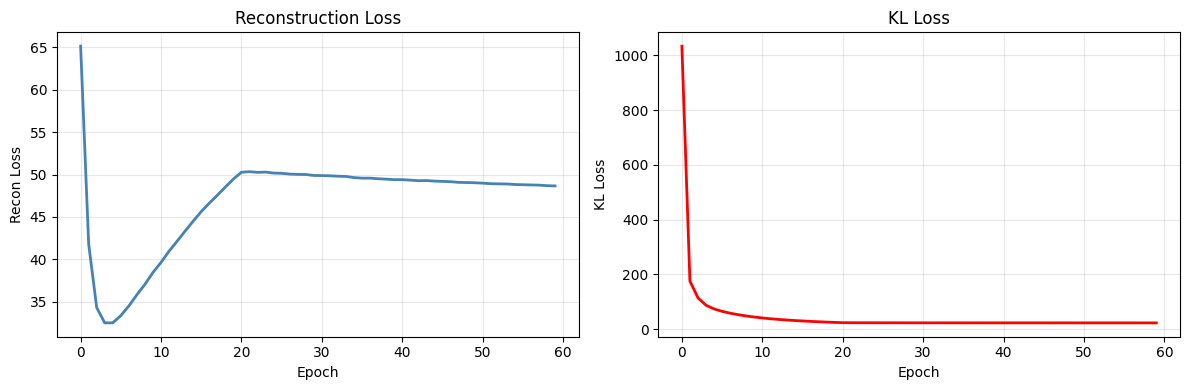

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['recon_loss'], color='steelblue', linewidth=2)
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('Recon Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['kl_loss'], color='red', linewidth=2)
plt.title('KL Loss')
plt.xlabel('Epoch')
plt.ylabel('KL Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Example Images generated from CVAE

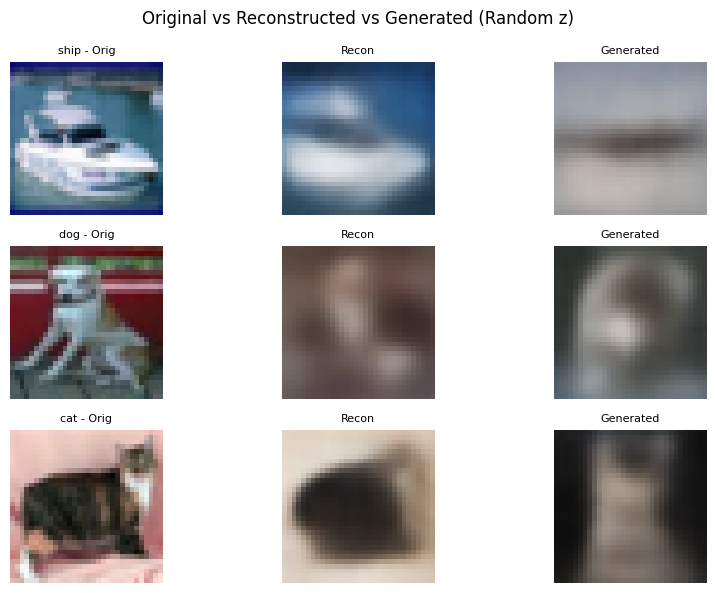

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Pick 3 random classes
selected_classes = np.random.choice(num_classes, 3, replace=False)

plt.figure(figsize=(9, 6))

for row, cls in enumerate(selected_classes):
    
    # Get indices of this class
    class_indices = np.where(np.argmax(y_test, axis=1) == cls)[0]
    
    # Pick one random sample from this class
    idx = np.random.choice(class_indices)
    
    x_sample = x_test[idx:idx+1]   # keep batch dim
    y_sample = y_test[idx:idx+1]

    # Reconstruction
    x_recon = final_cvae([x_sample, y_sample], training=False).numpy()

    # Random generation
    z_random = tf.random.normal(shape=(1, latent_dim))
    y_class  = tf.one_hot([cls], depth=num_classes)
    x_gen = final_cvae.decode(z_random, y_class).numpy()

    # --- Plotting ---
    # Original
    plt.subplot(3, 3, row*3 + 1)
    plt.imshow(x_sample[0])
    plt.title(f"{classes[cls]} - Orig", fontsize=8)
    plt.axis('off')

    # Reconstruction
    plt.subplot(3, 3, row*3 + 2)
    plt.imshow(x_recon[0])
    plt.title("Recon", fontsize=8)
    plt.axis('off')

    # Generated
    plt.subplot(3, 3, row*3 + 3)
    plt.imshow(x_gen[0])
    plt.title("Generated", fontsize=8)
    plt.axis('off')

plt.suptitle("Original vs Reconstructed vs Generated (Random z)", fontsize=12)
plt.tight_layout()
plt.show()

## 2D Visualisation of Latent Space

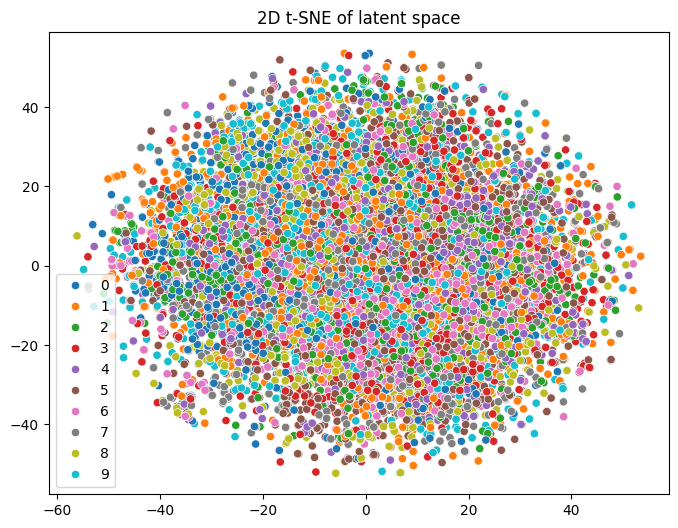

In [14]:
z_mean, _ = final_cvae.encode(x_test, y_test)  # get latent means
z_mean = z_mean.numpy()

z_emb = TSNE(n_components=2).fit_transform(z_mean)
labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(8,6))
sns.scatterplot(x=z_emb[:,0], y=z_emb[:,1], hue=labels, palette="tab10", legend="full")
plt.title("2D t-SNE of latent space")
plt.show()

## Final Losses on Test Set

In [15]:
final_loss = final_cvae.evaluate([x_test, y_test], x_test, batch_size=128)
print("Final Loss", final_loss)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - kl_loss: 22.3671 - recon_loss: 50.1324
Final Loss [50.10560607910156, 22.41766929626465]


## Image Generation for Data Augmentation

In [16]:
def generate_images(cvae, n_per_class, latent_dim, num_classes):
    all_images = []
    all_labels = []

    for cls in range(num_classes):
        # Random points sampled from standard normal — shape (n_per_class, 256)
        z = np.random.normal(size=(n_per_class, latent_dim)).astype('float32')

        # One-hot label for this class — shape (n_per_class, 10)
        y = np.zeros((n_per_class, num_classes), dtype='float32')
        y[:, cls] = 1.0

        # Decoder only — encoder is completely skipped
        imgs = cvae.decode(z, y).numpy()

        all_images.append(imgs)
        all_labels.append(y)

    images = np.concatenate(all_images, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    return images, labels

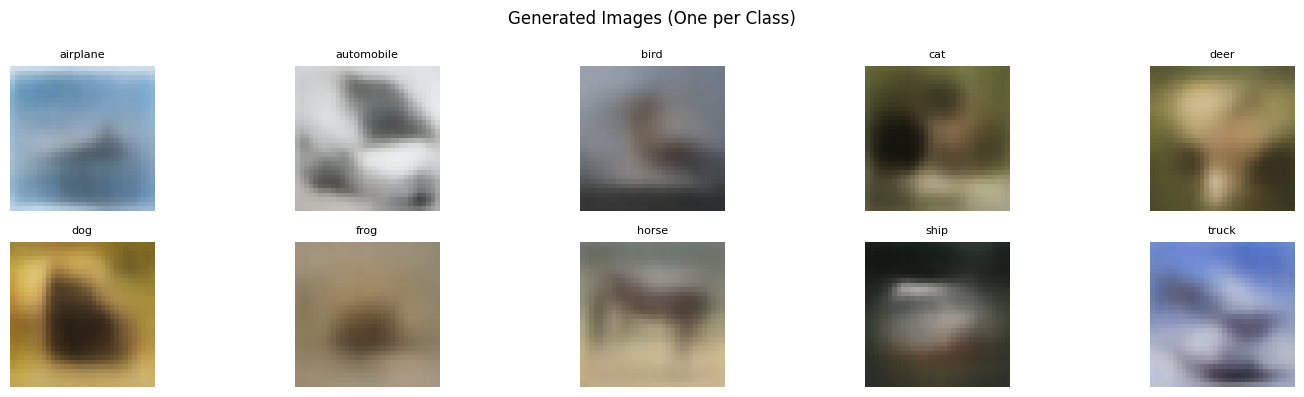

In [17]:
gen_x, gen_y = generate_images(final_cvae, 10, latent_dim, num_classes)

plt.figure(figsize=(15, 4))

for cls in range(num_classes):
    # Get all images of this class
    class_indices = np.where(np.argmax(gen_y, axis=1) == cls)[0]
    
    # Pick one random image from this class
    idx = np.random.choice(class_indices)
    
    plt.subplot(2, 5, cls + 1)
    plt.imshow(gen_x[idx])
    plt.title(classes[cls], fontsize=8)
    plt.axis('off')

plt.suptitle('Generated Images (One per Class)')
plt.tight_layout()
plt.show()

## CNN Architecture

In [18]:

def build_cnn():
    inp = layers.Input((32, 32, 3))
    x   = layers.Conv2D(32, 3, strides=1, padding='same')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Conv2D(64, 3, strides=1, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(128)(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(learning_rate=0.0005),
        metrics=['accuracy']
    )
    return model

### Validation Dataset Split

In [19]:

y_labels = np.argmax(y_train, axis=1)

x_train_cnn, x_val, y_train_cnn, y_val = train_test_split(
    x_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_labels
)

print(f"CNN Train: {x_train_cnn.shape}")
print(f"Val:       {x_val.shape}")
print(f"x_train (full, for CVAE reference): {x_train.shape}")

CNN Train: (45000, 32, 32, 3)
Val:       (5000, 32, 32, 3)
x_train (full, for CVAE reference): (50000, 32, 32, 3)


In [20]:
GEN_COUNTS = [10, 50, 100]

datasets  = {}

# Baseline uses only the CNN training split — NOT full x_train
datasets[0] = (x_train_cnn.copy(), y_train_cnn.copy())

for n_gen in GEN_COUNTS:
    gen_x, gen_y = generate_images(final_cvae, n_gen, latent_dim, num_classes)

    # Augment on top of x_train_cnn — val images are safely excluded
    x_aug = np.concatenate([x_train_cnn, gen_x], axis=0)
    y_aug = np.concatenate([y_train_cnn, gen_y], axis=0)

    # Shuffle so fake and real images are mixed in every batch
    idx   = np.random.permutation(len(x_aug))
    x_aug = x_aug[idx]
    y_aug = y_aug[idx]

    datasets[n_gen] = (x_aug, y_aug)
    print(f"Aug-{n_gen}: {x_aug.shape[0]} total training samples")

Aug-10: 45100 total training samples
Aug-50: 45500 total training samples
Aug-100: 46000 total training samples


## CNN Training

In [21]:
histories    = {}
final_models = {}
labels_map   = {
    0:   'Baseline',
    10:  'Aug +10/class',
    50:  'Aug +50/class',
    100: 'Aug +100/class'
}

for n_gen, (x_tr, y_tr) in datasets.items():
    print(f"\n{'='*50}")
    print(f"Training: {labels_map[n_gen]}  |  {x_tr.shape[0]} samples")
    print(f"{'='*50}")

    model   = build_cnn()
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=128,
        shuffle=True,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy: {test_acc:.4f}")

    histories[n_gen]    = history
    final_models[n_gen] = model


Training: Baseline  |  45000 samples
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3586 - loss: 1.9111 - val_accuracy: 0.3002 - val_loss: 2.2119
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5482 - loss: 1.2745 - val_accuracy: 0.5620 - val_loss: 1.2164
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6191 - loss: 1.0892 - val_accuracy: 0.6370 - val_loss: 1.0343
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6614 - loss: 0.9649 - val_accuracy: 0.5842 - val_loss: 1.2050
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6934 - loss: 0.8811 - val_accuracy: 0.6514 - val_loss: 0.9840
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7169 - loss: 0.8098 - val_accuracy: 0.6846 - val_loss: 0.8966
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7318 - loss: 0.7595 - val_accuracy: 0.6870 - val_loss: 0.9184
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 

## Accuracy & Loss Trends over Epochs

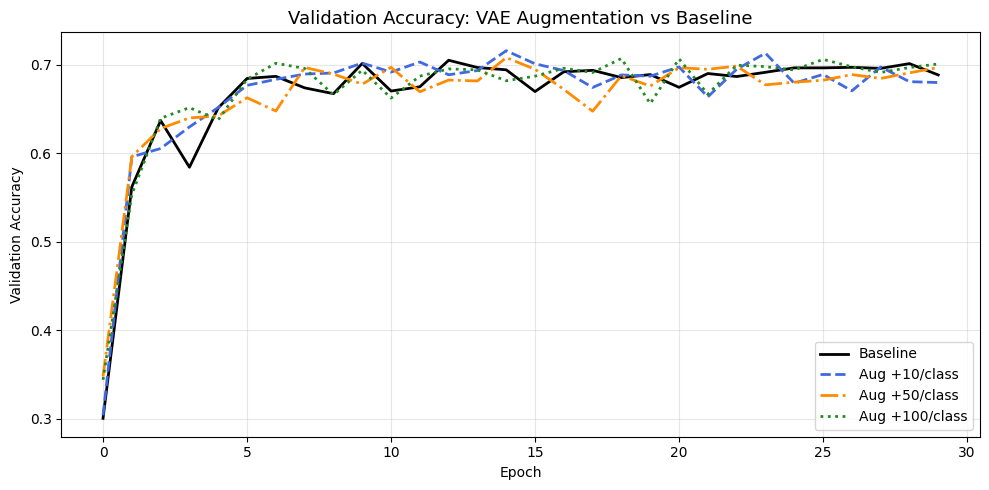

In [22]:
plt.figure(figsize=(10, 5))

colors     = ['black', 'royalblue', 'darkorange', 'forestgreen']
linestyles = ['-', '--', '-.', ':']

for (n_gen, history), color, ls in zip(histories.items(), colors, linestyles):
    plt.plot(
        history.history['val_accuracy'],
        label=labels_map[n_gen],
        color=color,
        linestyle=ls,
        linewidth=2
    )

plt.title('Validation Accuracy: VAE Augmentation vs Baseline', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('val_accuracy_comparison.png', dpi=150)
plt.show()

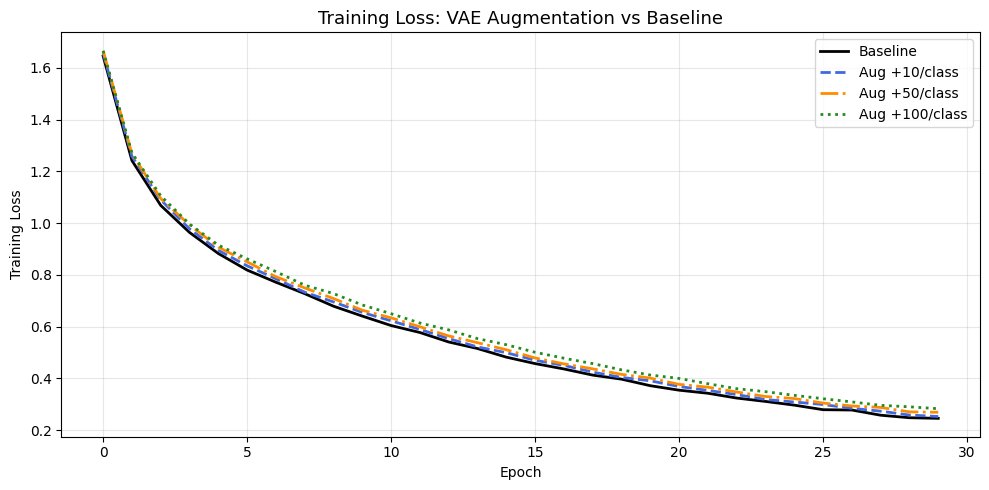

In [23]:
plt.figure(figsize=(10, 5))

for (n_gen, history), color, ls in zip(histories.items(), colors, linestyles):
    plt.plot(
        history.history['loss'],
        label=labels_map[n_gen],
        color=color,
        linestyle=ls,
        linewidth=2
    )

plt.title('Training Loss: VAE Augmentation vs Baseline', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_loss_comparison.png', dpi=150)
plt.show()

## Final Evaluation on Test Dataset

In [24]:
print(f"\n{'Model':<20} {'Test Accuracy':>15}")
print("-" * 36)

for n_gen, model in final_models.items():
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{labels_map[n_gen]:<20} {acc:.4f}")


Model                  Test Accuracy
------------------------------------
Baseline             0.6798
Aug +10/class        0.6728
Aug +50/class        0.6820
Aug +100/class       0.6879


### Class-specific Metrics

In [25]:
for n_gen in [0, 10, 50, 100]:
    model  = final_models[n_gen]
    preds  = model.predict(x_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f"\n{'='*55}")
    print(f"  Classification Report — {labels_map[n_gen]}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=classes))


  Classification Report — Baseline
              precision    recall  f1-score   support

    airplane       0.68      0.74      0.71      1000
  automobile       0.78      0.82      0.80      1000
        bird       0.50      0.67      0.58      1000
         cat       0.47      0.55      0.51      1000
        deer       0.66      0.61      0.63      1000
         dog       0.65      0.50      0.56      1000
        frog       0.71      0.78      0.74      1000
       horse       0.75      0.72      0.73      1000
        ship       0.91      0.71      0.80      1000
       truck       0.84      0.70      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.70      0.68      0.68     10000
weighted avg       0.70      0.68      0.68     10000


  Classification Report — Aug +10/class
              precision    recall  f1-score   support

    airplane       0.66      0.74      0.70      1000
  automobile       0.84      0.73      0.78      1000
 

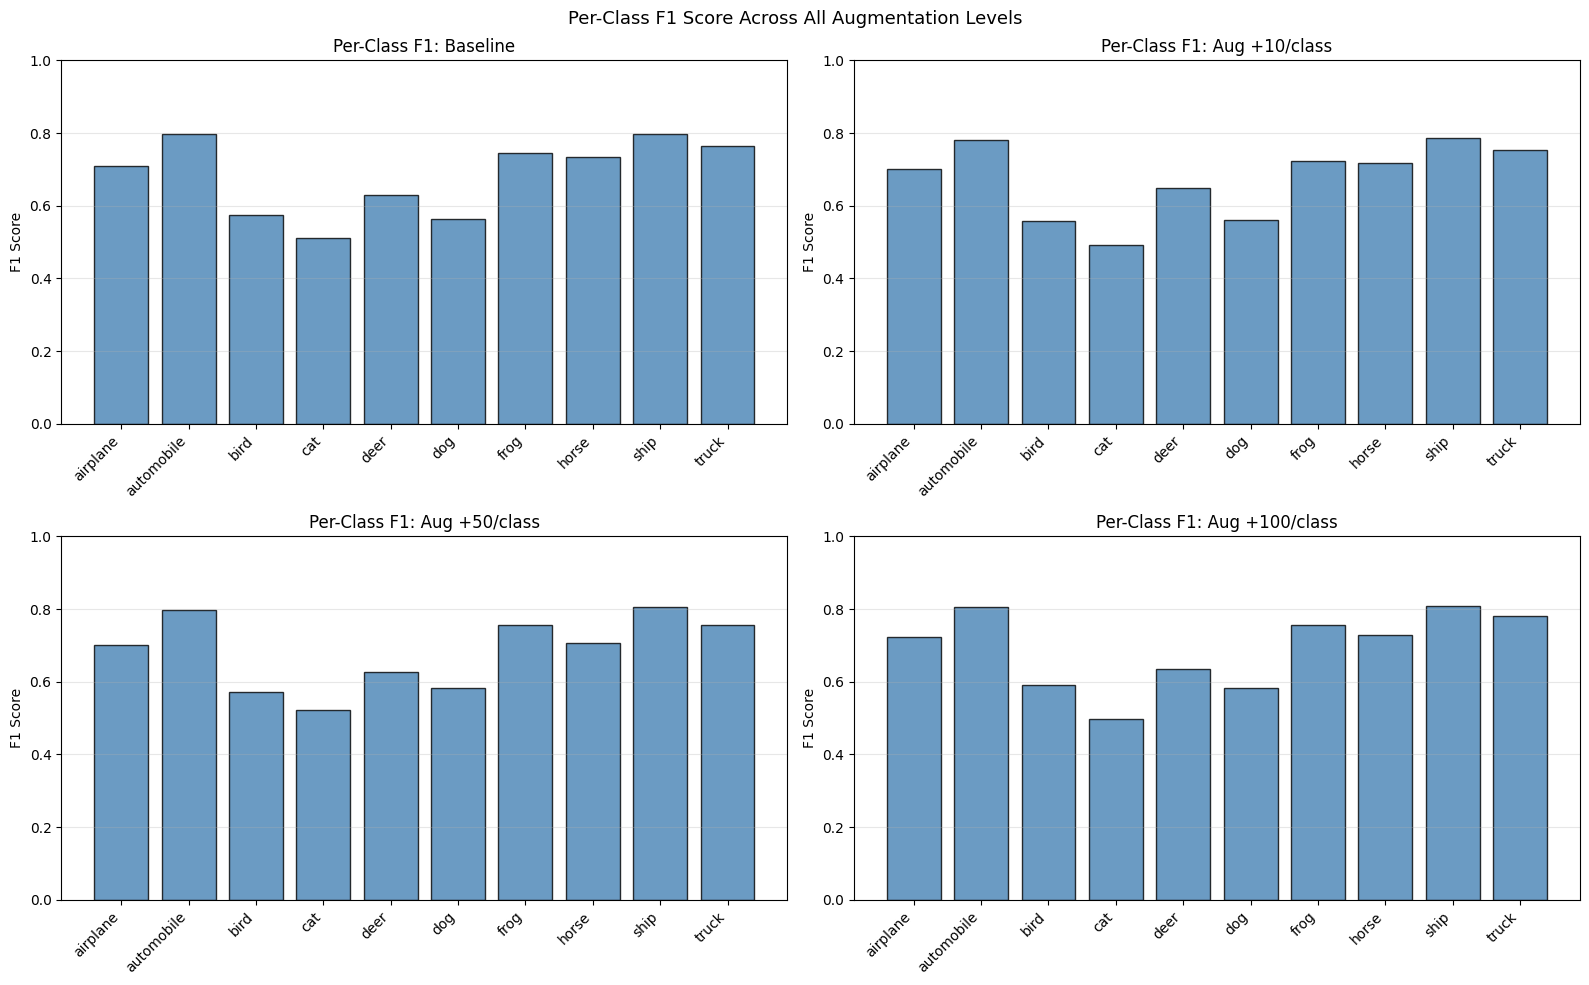

In [30]:


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, n_gen in zip(axes, [0, 10, 50, 100]):
    model  = final_models[n_gen]
    preds  = model.predict(x_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    report    = classification_report(y_true, y_pred,
                                      target_names=classes,
                                      output_dict=True)
    f1_scores = [report[cls]['f1-score'] for cls in classes]

    ax.bar(classes, f1_scores, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(f'Per-Class F1: {labels_map[n_gen]}', fontsize=12)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Class F1 Score Across All Augmentation Levels', fontsize=13)
plt.tight_layout()
plt.savefig('perclass_f1_all.png', dpi=150)
plt.show()